Voor dit practicum is gebruik gemaakt van de Flowers Dataset (https://www.kaggle.com/datasets/imsparsh/flowers-dataset?select=train) en wordt de vraag over RGB vs Grayscale beantwoord.


# 1. IMPORTS

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image_dataset_from_directory
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import seaborn as sns

print("TensorFlow version:", tf.__version__)

# 2. INSTELLINGEN

In [2]:
DATASET_PATH = r"C:\Users\elios\DPDEE-01\Opdrachten\Practicums\Opdracht4\train"

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 10
SEED = 42

# 3. DATA LADEN FUNCTIE

In [3]:
def load_datasets(color_mode='rgb'):
    """
    Laadt train en validation datasets.
    color_mode = 'rgb' of 'grayscale'
    """
    train_ds = image_dataset_from_directory(
        DATASET_PATH,
        validation_split=0.2,
        subset="training",
        seed=SEED,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        color_mode=color_mode
    )

    val_ds = image_dataset_from_directory(
        DATASET_PATH,
        validation_split=0.2,
        subset="validation",
        seed=SEED,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        color_mode=color_mode
    )

    class_names = train_ds.class_names

    # performance optimalisatie
    AUTOTUNE = tf.data.AUTOTUNE
    train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
    val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

    return train_ds, val_ds, class_names

Found 2198 images belonging to 5 classes.
Found 548 images belonging to 5 classes.
Found 0 images belonging to 0 classes.


# 4. CNN MODEL FUNCTIE

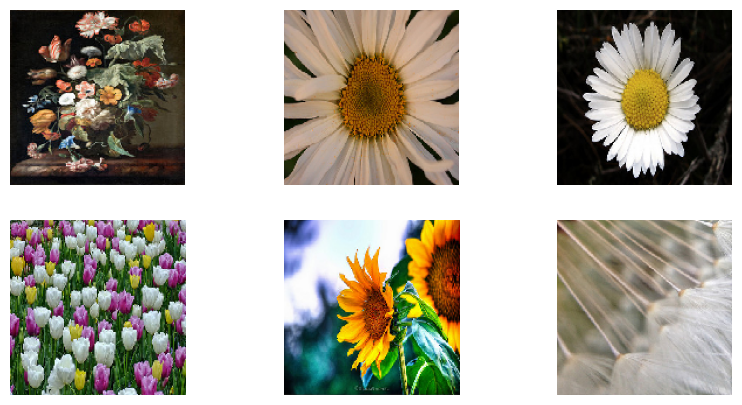

In [4]:
def build_cnn(input_shape, num_classes):
    model = models.Sequential([
        layers.Rescaling(1./255, input_shape=input_shape),

        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D(),

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D(),

        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# 5. TRAINEN + EVALUEREN

In [9]:
def train_and_evaluate(color_mode='rgb'):
    
    print(f"TRAINING START: {color_mode.upper()}")

    train_ds, val_ds, class_names = load_datasets(color_mode=color_mode)

    num_classes = len(class_names)

    if color_mode == 'rgb':
        input_shape = (IMG_SIZE[0], IMG_SIZE[1], 3)
    else:
        input_shape = (IMG_SIZE[0], IMG_SIZE[1], 1)

    model = build_cnn(input_shape, num_classes)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS
    )

    # Voorspellingen verzamelen
    y_true = []
    y_pred = []

    for images, labels in val_ds:
        preds = model.predict(images, verbose=0)
        preds = np.argmax(preds, axis=1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f"\nRESULTATEN ({color_mode.upper()}):")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    return model, history, y_true, y_pred, class_names, {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1
    }

# 6. GRAFIEKEN

In [6]:
def plot_history(history, title_prefix="Model"):
    plt.figure(figsize=(12, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{title_prefix} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{title_prefix} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

Epoch 1/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 18s 244ms/step - accuracy: 0.4013 - loss: 1.3834 - val_accuracy: 0.4836 - val_loss: 1.2636
Epoch 2/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 16s 232ms/step - accuracy: 0.5546 - loss: 1.0794 - val_accuracy: 0.4489 - val_loss: 1.2840
Epoch 3/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 16s 235ms/step - accuracy: 0.6178 - loss: 0.9639 - val_accuracy: 0.5949 - val_loss: 1.0714
Epoch 4/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 17s 240ms/step - accuracy: 0.7011 - loss: 0.7793 - val_accuracy: 0.5748 - val_loss: 1.1103
Epoch 5/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 17s 247ms/step - accuracy: 0.7598 - loss: 0.6478 - val_accuracy: 0.5730 - val_loss: 1.1422
Epoch 6/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 16s 237ms/step - accuracy: 0.8248 - loss: 0.4687 - val_accuracy: 0.5894 - val_loss: 1.2040
Epoch 7/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 16s 234ms/step - accuracy: 0.8858 - loss: 0.3189 - val_accuracy: 0.6168 - val_loss: 1.4099
Epoch 8/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 16s 236ms/step - accuracy: 0.9395 - loss: 0.1863 - val_accu

# 7. CONFUSION MATRIX

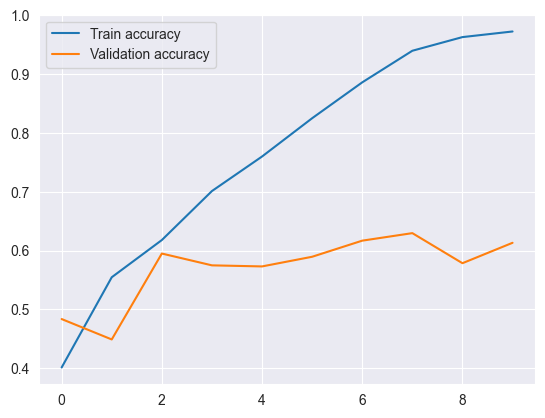

In [7]:
def plot_confusion(y_true, y_pred, class_names, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(rotation=45)
    plt.yticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 8. RGB MODEL TRAINEN

In [8]:
rgb_model, rgb_history, rgb_y_true, rgb_y_pred, class_names, rgb_results = train_and_evaluate(color_mode='rgb')

ValueError: The PyDataset has length 0

# 9. GRAYSCALE MODEL TRAINEN

In [66]:
gray_model, gray_history, gray_y_true, gray_y_pred, _, gray_results = train_and_evaluate(color_mode='grayscale')

TRAINING START: GRAYSCALE
Found 2746 files belonging to 5 classes.
Using 2197 files for training.
Found 2746 files belonging to 5 classes.
Using 549 files for validation.
Epoch 1/10


C:\Users\elios\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


69/69 ━━━━━━━━━━━━━━━━━━━━ 37s 464ms/step - accuracy: 0.2381 - loss: 1.6119 - val_accuracy: 0.3333 - val_loss: 1.5393
Epoch 2/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 32s 466ms/step - accuracy: 0.3072 - loss: 1.5222 - val_accuracy: 0.3752 - val_loss: 1.4472
Epoch 3/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 33s 481ms/step - accuracy: 0.3819 - loss: 1.4286 - val_accuracy: 0.3661 - val_loss: 1.4009
Epoch 4/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 33s 477ms/step - accuracy: 0.4442 - loss: 1.3190 - val_accuracy: 0.4627 - val_loss: 1.3359
Epoch 5/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 33s 482ms/step - accuracy: 0.5198 - loss: 1.1751 - val_accuracy: 0.4681 - val_loss: 1.2805
Epoch 6/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 32s 468ms/step - accuracy: 0.5931 - loss: 1.0242 - val_accuracy: 0.4918 - val_loss: 1.2864
Epoch 7/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 33s 477ms/step - accuracy: 0.6604 - loss: 0.8656 - val_accuracy: 0.4845 - val_loss: 1.3908
Epoch 8/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 33s 474ms/step - accuracy: 0.7223 - loss: 0.7313 - val_accuracy: 0.457

# 10. RESULTATEN VERGELIJKEN

In [67]:
print("VERGELIJKING RGB VS GRAYSCALE")

print(f"{'Metric':<12} {'RGB':<10} {'Grayscale':<10}")
print("-" * 35)
print(f"{'Accuracy':<12} {rgb_results['accuracy']:<10.4f} {gray_results['accuracy']:<10.4f}")
print(f"{'Precision':<12} {rgb_results['precision']:<10.4f} {gray_results['precision']:<10.4f}")
print(f"{'Recall':<12} {rgb_results['recall']:<10.4f} {gray_results['recall']:<10.4f}")
print(f"{'F1-score':<12} {rgb_results['f1_score']:<10.4f} {gray_results['f1_score']:<10.4f}")

VERGELIJKING RGB VS GRAYSCALE
Metric       RGB        Grayscale 
-----------------------------------
Accuracy     0.6958     0.4772    
Precision    0.7117     0.5446    
Recall       0.6958     0.4772    
F1-score     0.6899     0.4781    


# 11. GRAFIEKEN LATEN ZIEN

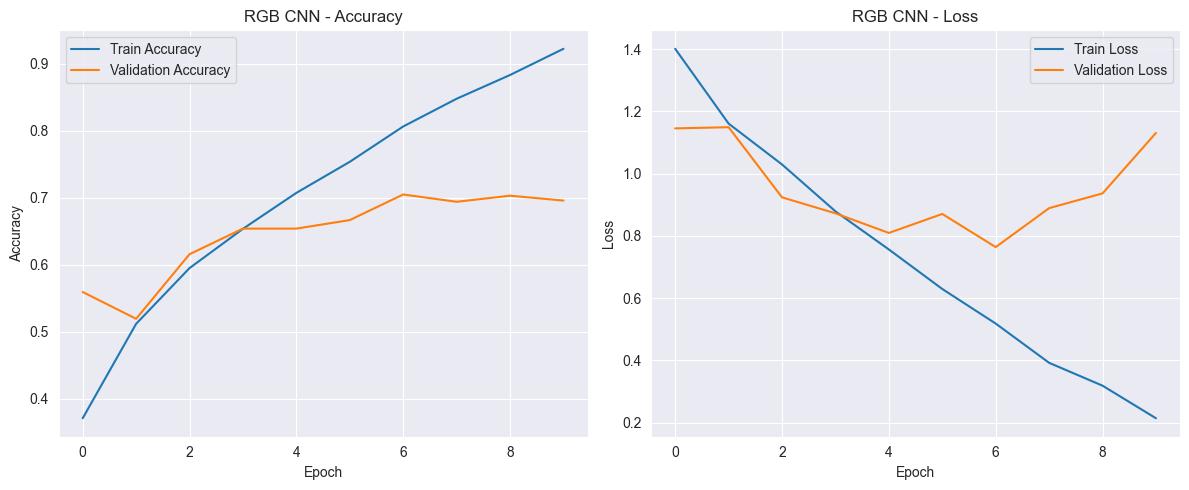

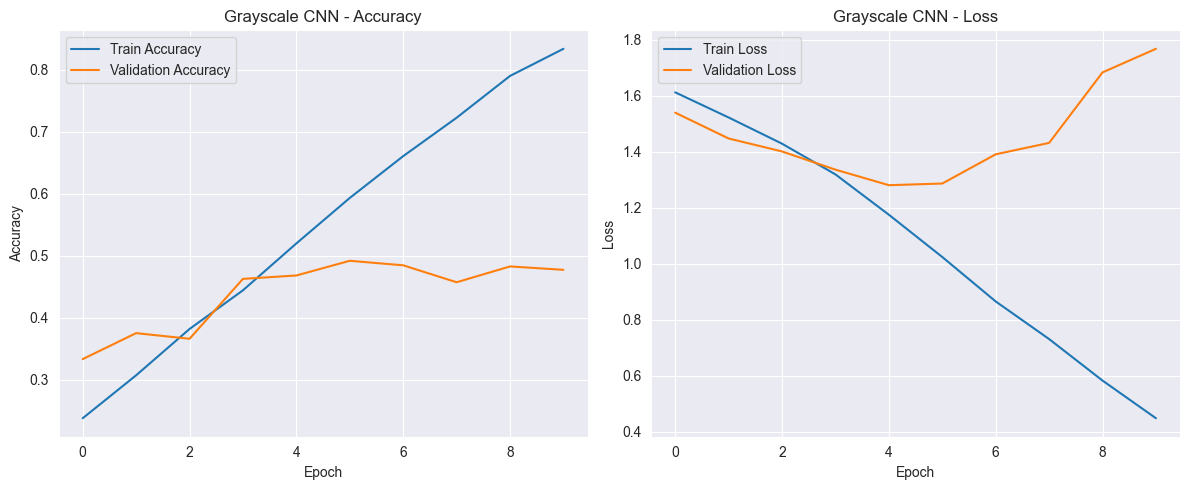

In [68]:
plot_history(rgb_history, title_prefix="RGB CNN")
plot_history(gray_history, title_prefix="Grayscale CNN")

# 12. CONFUSION MATRICES

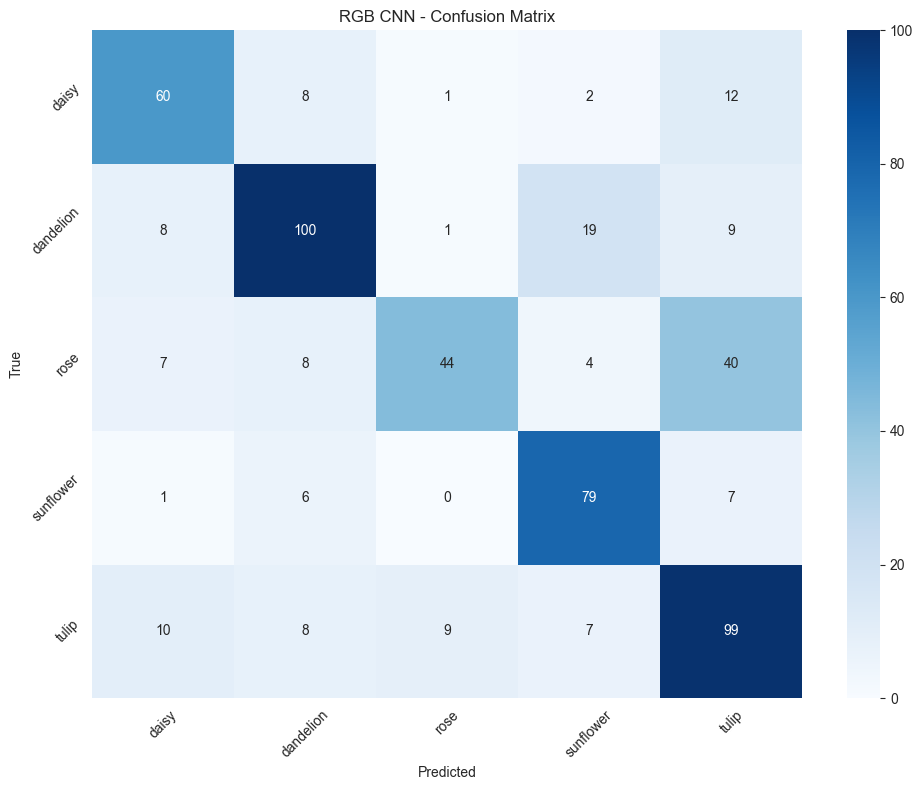

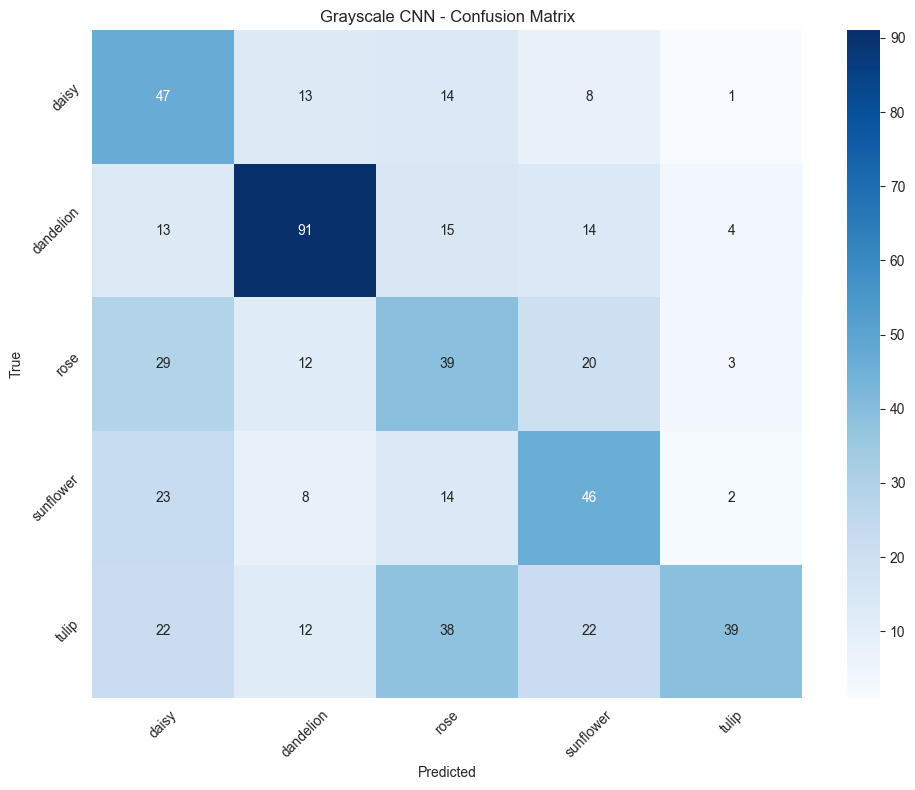

In [69]:
plot_confusion(rgb_y_true, rgb_y_pred, class_names, title="RGB CNN - Confusion Matrix")
plot_confusion(gray_y_true, gray_y_pred, class_names, title="Grayscale CNN - Confusion Matrix")

# 13. CONCLUSIE

De resultaten laten een duidelijk verschil zien tussen beide modellen. Het model dat getraind is op RGB-afbeeldingen behaalde een accuracy van 69,58%, terwijl het model met grijswaardenafbeeldingen een accuracy behaalde van 47,72%. Ook de andere prestatiematen lagen hoger voor het RGB-model: de precision steeg van 54,46% naar 71,17%, de recall van 47,72% naar 69,58%, en de F1-score van 47,81% naar 68,99%.

Op basis van deze resultaten kan worden geconcludeerd dat kleurinformatie duidelijk waarde toevoegt aan de classificatie van bloemen. Dit is logisch, omdat bloemsoorten zich niet alleen onderscheiden op basis van vorm en structuur, maar ook op basis van kleur, tint en kleurpatronen. Wanneer afbeeldingen worden omgezet naar grijswaarden, gaat deze informatie verloren, waardoor het model minder onderscheid kan maken tussen verschillende bloemklassen.

De onderzoeksvraag kan daarom worden beantwoord met:
nee, grijswaarden leveren niet dezelfde performance op als RGB-afbeeldingen; kleurinformatie voegt aantoonbaar iets toe aan de classificatie.

| Metric    | RGB    | Grayscale |
| --------- | ------ | --------- |
| Accuracy  | 69,58% | 47,72%    |
| Precision | 71,17% | 54,46%    |
| Recall    | 69,58% | 47,72%    |
| F1-score  | 68,99% | 47,81%    |

## Antwoord op de onderzoeksvraag:
Nee, een CNN behaalt in deze dataset niet dezelfde performance op grijswaardenafbeeldingen als op RGB-afbeeldingen. De prestaties zijn op alle gemeten onderdelen lager bij grayscale. Dit laat zien dat kleurinformatie een belangrijke rol speelt bij het classificeren van bloemen.

## Discussie
Een mogelijke verklaring voor het grote prestatieverschil is dat bloemen vaak op elkaar kunnen lijken qua vorm, terwijl kleur juist een belangrijk onderscheidend kenmerk vormt. Denk bijvoorbeeld aan verschillen tussen gele, rode, witte of paarse bloemen. Door de afbeeldingen om te zetten naar grijswaarden verliest het model een deel van de informatie die nodig is om deze klassen goed uit elkaar te houden.

Daarnaast moet worden opgemerkt dat de absolute prestaties van beide modellen nog niet perfect zijn. Dit kan mogelijk verbeterd worden door:

- meer epochs te trainen
- een beter CNN te gebruiken
- verder te optimaliseren

Zelfs dan is het verschil tussen RGB en grayscale groot genoeg om duidelijk te laten zien dat kleurinformatie een relevante bijdrage levert.